# Figure 5: Population-scale genotype-driven susceptibility simulations

This notebook regenerates a population-scale simulation figure from the local
**ExposoGraph** package.

Package-alignment notes:

- The simulation uses the curated ancestry-specific genotype distributions in
  `ExposoGraph.population_simulation._core`, with haplotype blocks enabled for
  gene clusters represented by the package.
- The five displayed groups are mapped to the package labels:
  European (EUR), East Asian (EAS), African/African American (AFR),
  Admixed American (AMR), and South Asian (SAS).
- Lifestyle and occupational exposure inputs are fixed to Tier 1/background
  conditions to focus on genotype-driven flux variation.
- The package does not expose a single built-in population "composite risk
  score" matching the draft manuscript text. This notebook therefore defines an
  explicit relative composite score as the geometric mean of per-class
  activation/detoxification net ratios after class-wise median normalization.
- The current package does not sample CYP1B1*3/Val432 in the population
  simulation table, so Figure 5 uses sampled ALDH2, GSTM1, GSTT1, CYP1A1, and
  NAT2 summaries that are actually available in ExposoGraph.


In [6]:
from __future__ import annotations

import csv
import math
import random
import statistics
import sys
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# Make the notebook robust whether it is launched from repo root or Figures_Notebook/.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "ExposoGraph").is_dir() and (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the ExposoGraph repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUTPUT_DIR = REPO_ROOT / "Figures_Notebook" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_PER_ANCESTRY = 10_000
SEED = 20260430
TISSUE = "Liver"
USE_HAPLOTYPES = True

ANCESTRIES = OrderedDict(
    [
        ("EUR", "European"),
        ("EAS", "East Asian"),
        ("AFR", "African"),
        ("AMR", "Admixed American"),
        ("SAS", "South Asian"),
    ]
)

DISPLAY_NAMES = {
    "EUR": "European",
    "EAS": "East Asian",
    "AFR": "African/African American",
    "AMR": "Latino/Admixed",
    "SAS": "South Asian",
}

PALETTE = {
    "EUR": "#007c89",
    "EAS": "#d89c00",
    "AFR": "#7b5ea7",
    "AMR": "#b65a32",
    "SAS": "#4f8f46",
}

plt.rcParams.update(
    {
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    }
)


## Simulate ancestry-forced synthetic genotypes

The public `generate_synthetic_cohort()` function samples a mixed population by
default. For Figure 5, we use the same package frequency tables but force each
ancestry stratum to exactly 10,000 synthetic individuals.


In [7]:
from ExposoGraph.flux_engine import compute_full_profile
from ExposoGraph.population_simulation._core import (
    ALLELE_FREQUENCIES,
    HAPLOTYPE_BLOCKS,
    _genes_covered_by_blocks,
    _weighted_pick,
    sample_haplotype_block,
)


def sample_genotypes_for_ancestry(
    rng: random.Random,
    ancestry_label: str,
    *,
    use_haplotypes: bool = True,
) -> dict[str, str]:
    if not use_haplotypes:
        return {
            gene: _weighted_pick(rng, per_ancestry[ancestry_label])
            for gene, per_ancestry in ALLELE_FREQUENCIES.items()
        }

    genotypes: dict[str, str] = {}
    covered_genes = _genes_covered_by_blocks()
    for block_name in HAPLOTYPE_BLOCKS:
        genotypes.update(sample_haplotype_block(rng, block_name, ancestry_label))

    for gene, per_ancestry in ALLELE_FREQUENCIES.items():
        if gene in covered_genes:
            continue
        genotypes[gene] = _weighted_pick(rng, per_ancestry[ancestry_label])

    return genotypes


def genotype_flags(genotypes: dict[str, str]) -> dict[str, int]:
    return {
        "ALDH2_star2_carrier": int("*2" in genotypes.get("ALDH2", "")),
        "ALDH2_star2_homozygote": int(genotypes.get("ALDH2", "") == "*2/*2"),
        "GSTM1_null": int(genotypes.get("GSTM1", "") == "null"),
        "GSTT1_null": int(genotypes.get("GSTT1", "") == "null"),
        "CYP1A1_star2A_carrier": int("*2A" in genotypes.get("CYP1A1", "")),
        "NAT2_slow": int(genotypes.get("NAT2", "") == "slow"),
    }


rng = random.Random(SEED)
raw_rows: list[dict[str, object]] = []
class_ratio_rows: list[dict[str, object]] = []
all_class_names: list[str] | None = None

for ancestry_code, ancestry_label in ANCESTRIES.items():
    for index in range(N_PER_ANCESTRY):
        genotypes = sample_genotypes_for_ancestry(
            rng,
            ancestry_label,
            use_haplotypes=USE_HAPLOTYPES,
        )
        profile = compute_full_profile(genotypes, tissue=TISSUE)
        if all_class_names is None:
            all_class_names = list(profile.per_class_results)

        person_id = f"{ancestry_code}{index:05d}"
        flags = genotype_flags(genotypes)
        row: dict[str, object] = {
            "person_id": person_id,
            "ancestry_code": ancestry_code,
            "ancestry_label": ancestry_label,
            "display_name": DISPLAY_NAMES[ancestry_code],
            "GSTM1": genotypes.get("GSTM1", ""),
            "GSTT1": genotypes.get("GSTT1", ""),
            "ALDH2": genotypes.get("ALDH2", ""),
            "NAT2": genotypes.get("NAT2", ""),
            "CYP1A1": genotypes.get("CYP1A1", ""),
            "CYP2E1": genotypes.get("CYP2E1", ""),
            **flags,
        }

        high_class_count = 0
        elevated_or_high_count = 0
        for class_name, result in profile.per_class_results.items():
            ratio = float(result.net_ratio)
            risk = result.risk_classification.value
            row[f"{class_name}_net_ratio"] = ratio
            row[f"{class_name}_risk"] = risk
            high_class_count += int(risk == "HIGH")
            elevated_or_high_count += int(risk in {"ELEVATED", "HIGH"})
            class_ratio_rows.append(
                {
                    "person_id": person_id,
                    "ancestry_code": ancestry_code,
                    "ancestry_label": ancestry_label,
                    "carcinogen_class": class_name,
                    "net_ratio": ratio,
                    "risk_classification": risk,
                    "model_kind": getattr(result, "model_kind", ""),
                    "parameter_source": getattr(result, "parameter_source", ""),
                }
            )

        row["high_class_count"] = high_class_count
        row["elevated_or_high_class_count"] = elevated_or_high_count
        raw_rows.append(row)

all_class_names = all_class_names or []
print(f"Simulated {len(raw_rows):,} individuals across {len(ANCESTRIES)} ancestry groups.")
print(f"Carcinogen classes modeled: {len(all_class_names)}")


/Users/julhashkazi/Documents/ExposoGraph_work/ExposoGraph/flux_engine.py:1599: UserWarning: Unrecognized diplotype '*1A/*1F' for gene 'CYP1A2'; defaulting to NM (1.0)
  gm1a2 = genotype_modifier(genotypes.get("CYP1A2", "NM"), "CYP1A2")
/Users/julhashkazi/Documents/ExposoGraph_work/ExposoGraph/flux_engine.py:1849: UserWarning: Unrecognized diplotype '*1A/*1F' for gene 'CYP1A2'; defaulting to NM (1.0)
  gm1a2 = genotype_modifier(genotypes.get("CYP1A2", "NM"), "CYP1A2")


Simulated 50,000 individuals across 5 ancestry groups.
Carcinogen classes modeled: 15


## Composite score definition

For each carcinogen class, the activation/detoxification net ratio is divided by
the class-wise median across all simulated individuals. The composite score is
the geometric mean of these normalized class ratios. This makes the score a
relative pharmacogenomic susceptibility index centered near 1.0, rather than an
absolute cancer-risk estimate.


In [8]:
EPS = 1e-9

class_medians: dict[str, float] = {}
for class_name in all_class_names:
    values = [
        float(row[f"{class_name}_net_ratio"])
        for row in raw_rows
        if float(row[f"{class_name}_net_ratio"]) > 0
    ]
    class_medians[class_name] = statistics.median(values) if values else 1.0

for row in raw_rows:
    log_components: list[float] = []
    measured_log_components: list[float] = []
    for class_name in all_class_names:
        ratio = max(float(row[f"{class_name}_net_ratio"]), EPS)
        median = max(class_medians[class_name], EPS)
        normalized = ratio / median
        log_components.append(math.log(normalized))
        class_risk = str(row[f"{class_name}_risk"])
        if class_risk != "INSUFFICIENT_DATA":
            measured_log_components.append(math.log(normalized))

    composite_score = math.exp(sum(log_components) / len(log_components))
    row["relative_composite_score"] = round(composite_score, 6)
    row["relative_composite_log2"] = round(math.log2(composite_score), 6)

pooled_scores = sorted(float(row["relative_composite_score"]) for row in raw_rows)
upper_quartile_threshold = pooled_scores[round((len(pooled_scores) - 1) * 0.75)]
upper_decile_threshold = pooled_scores[round((len(pooled_scores) - 1) * 0.90)]

for row in raw_rows:
    score = float(row["relative_composite_score"])
    row["upper_quartile_susceptibility"] = int(score >= upper_quartile_threshold)
    row["upper_decile_susceptibility"] = int(score >= upper_decile_threshold)

print(f"Pooled upper-quartile threshold: {upper_quartile_threshold:.4f}")
print(f"Pooled upper-decile threshold: {upper_decile_threshold:.4f}")


Pooled upper-quartile threshold: 1.0705
Pooled upper-decile threshold: 1.1233


## Export source tables


In [9]:
def percentile(sorted_values: list[float], q: float) -> float:
    index = min(len(sorted_values) - 1, max(0, int(round((len(sorted_values) - 1) * q))))
    return sorted_values[index]


def geometric_mean(values: list[float]) -> float:
    positives = [max(float(value), EPS) for value in values]
    return math.exp(sum(math.log(value) for value in positives) / len(positives))


participant_csv = OUTPUT_DIR / "figure5_population_participant_scores.csv"
with participant_csv.open("w", newline="", encoding="utf-8") as handle:
    fieldnames = list(raw_rows[0].keys())
    writer = csv.DictWriter(handle, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(raw_rows)

summary_rows: list[dict[str, object]] = []
for ancestry_code, ancestry_label in ANCESTRIES.items():
    rows = [row for row in raw_rows if row["ancestry_code"] == ancestry_code]
    scores = sorted(float(row["relative_composite_score"]) for row in rows)
    p5 = percentile(scores, 0.05)
    p50 = percentile(scores, 0.50)
    p95 = percentile(scores, 0.95)
    summary_rows.append(
        {
            "ancestry_code": ancestry_code,
            "ancestry_label": ancestry_label,
            "display_name": DISPLAY_NAMES[ancestry_code],
            "n": len(rows),
            "geometric_mean_relative_score": round(geometric_mean(scores), 4),
            "median_relative_score": round(p50, 4),
            "p5_relative_score": round(p5, 4),
            "p95_relative_score": round(p95, 4),
            "p95_to_p5_fold_range": round(p95 / p5, 4) if p5 > 0 else "",
            "pct_upper_quartile": round(
                100 * sum(int(row["upper_quartile_susceptibility"]) for row in rows) / len(rows),
                2,
            ),
            "pct_upper_decile": round(
                100 * sum(int(row["upper_decile_susceptibility"]) for row in rows) / len(rows),
                2,
            ),
            "mean_high_class_count": round(
                sum(int(row["high_class_count"]) for row in rows) / len(rows),
                3,
            ),
            "mean_elevated_or_high_class_count": round(
                sum(int(row["elevated_or_high_class_count"]) for row in rows) / len(rows),
                3,
            ),
        }
    )

summary_csv = OUTPUT_DIR / "figure5_population_ancestry_summary.csv"
with summary_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(summary_rows[0].keys()))
    writer.writeheader()
    writer.writerows(summary_rows)

allele_rows: list[dict[str, object]] = []
flag_columns = [
    "ALDH2_star2_carrier",
    "ALDH2_star2_homozygote",
    "GSTM1_null",
    "GSTT1_null",
    "CYP1A1_star2A_carrier",
    "NAT2_slow",
]
for ancestry_code, ancestry_label in ANCESTRIES.items():
    rows = [row for row in raw_rows if row["ancestry_code"] == ancestry_code]
    for flag in flag_columns:
        allele_rows.append(
            {
                "ancestry_code": ancestry_code,
                "ancestry_label": ancestry_label,
                "display_name": DISPLAY_NAMES[ancestry_code],
                "variant_or_phenotype": flag,
                "frequency_percent": round(
                    100 * sum(int(row[flag]) for row in rows) / len(rows),
                    2,
                ),
            }
        )

allele_csv = OUTPUT_DIR / "figure5_population_sampled_allele_frequencies.csv"
with allele_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(allele_rows[0].keys()))
    writer.writeheader()
    writer.writerows(allele_rows)

class_summary_rows: list[dict[str, object]] = []
for ancestry_code, ancestry_label in ANCESTRIES.items():
    rows = [row for row in class_ratio_rows if row["ancestry_code"] == ancestry_code]
    for class_name in all_class_names:
        class_rows = [row for row in rows if row["carcinogen_class"] == class_name]
        ratios = sorted(float(row["net_ratio"]) for row in class_rows)
        class_summary_rows.append(
            {
                "ancestry_code": ancestry_code,
                "ancestry_label": ancestry_label,
                "carcinogen_class": class_name,
                "median_net_ratio": round(percentile(ratios, 0.50), 4),
                "p5_net_ratio": round(percentile(ratios, 0.05), 4),
                "p95_net_ratio": round(percentile(ratios, 0.95), 4),
                "pct_high": round(
                    100
                    * sum(row["risk_classification"] == "HIGH" for row in class_rows)
                    / len(class_rows),
                    2,
                ),
                "pct_elevated_or_high": round(
                    100
                    * sum(
                        row["risk_classification"] in {"ELEVATED", "HIGH"}
                        for row in class_rows
                    )
                    / len(class_rows),
                    2,
                ),
                "model_kind": class_rows[0]["model_kind"],
                "parameter_source": class_rows[0]["parameter_source"],
            }
        )

class_summary_csv = OUTPUT_DIR / "figure5_population_class_summary.csv"
with class_summary_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(class_summary_rows[0].keys()))
    writer.writeheader()
    writer.writerows(class_summary_rows)

print(participant_csv)
print(summary_csv)
print(allele_csv)
print(class_summary_csv)
for row in summary_rows:
    print(row)


/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure5_population_participant_scores.csv
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure5_population_ancestry_summary.csv
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure5_population_sampled_allele_frequencies.csv
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure5_population_class_summary.csv
{'ancestry_code': 'EUR', 'ancestry_label': 'European', 'display_name': 'European', 'n': 10000, 'geometric_mean_relative_score': 1.0326, 'median_relative_score': 1.0244, 'p5_relative_score': 0.9445, 'p95_relative_score': 1.1377, 'p95_to_p5_fold_range': 1.2045, 'pct_upper_quartile': 29.32, 'pct_upper_decile': 7.88, 'mean_high_class_count': 4.421, 'mean_elevated_or_high_class_count': 8.805}
{'ancestry_code': 'EAS', 'ancestry_label': 'East Asian', 'display_name': 'East Asian', 'n': 10000, 'geometric_mean_relative_score': 1.0701, 'median_relative_sco

## Render Figure 5


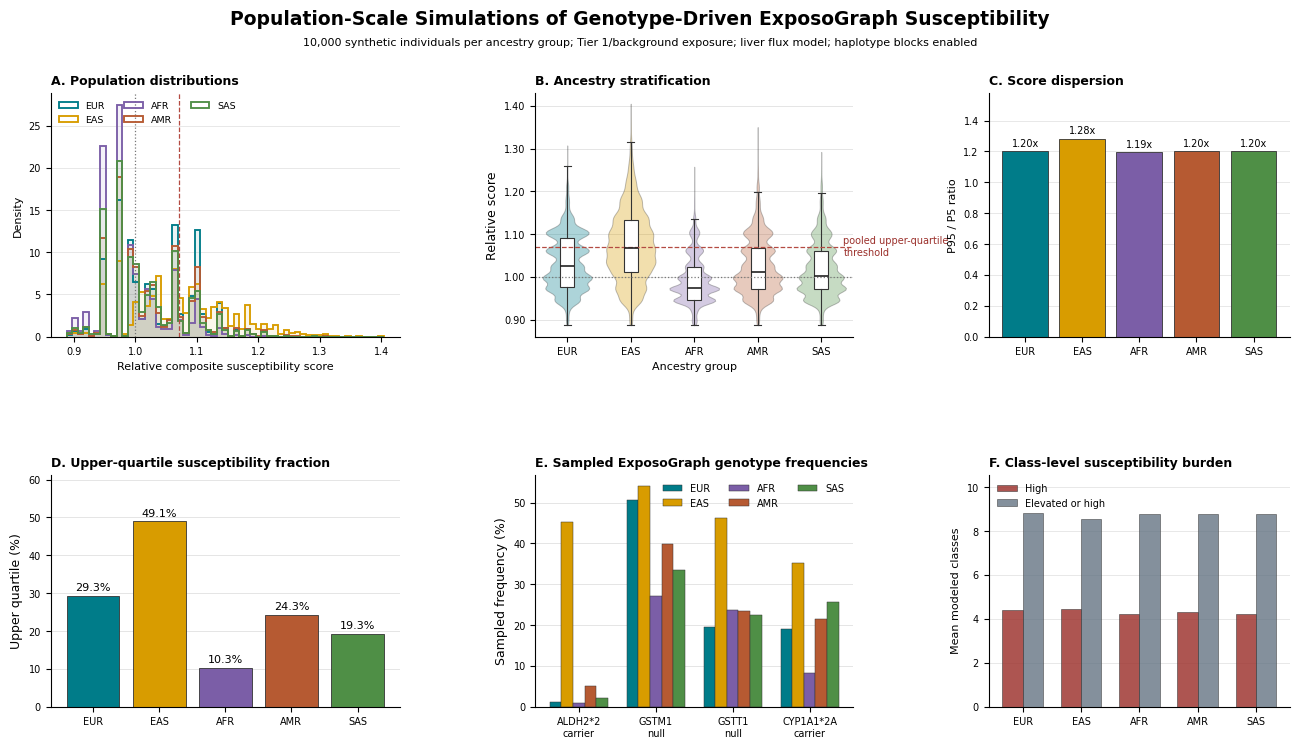

/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure5_population_scale_simulations.png
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure5_population_scale_simulations.pdf
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure5_population_scale_simulations.svg


In [10]:
fig = plt.figure(figsize=(13.4, 8.35), constrained_layout=False)
grid = fig.add_gridspec(2, 3, height_ratios=(1.05, 1.0), width_ratios=(1.1, 1.0, 0.95))
ax_density = fig.add_subplot(grid[0, 0])
ax_violin = fig.add_subplot(grid[0, 1])
ax_dispersion = fig.add_subplot(grid[0, 2])
ax_bar = fig.add_subplot(grid[1, 0])
ax_allele = fig.add_subplot(grid[1, 1])
ax_burden = fig.add_subplot(grid[1, 2])
fig.subplots_adjust(
    left=0.06,
    right=0.985,
    bottom=0.13,
    top=0.865,
    hspace=0.58,
    wspace=0.42,
)

codes = list(ANCESTRIES.keys())
score_groups = [
    [float(row["relative_composite_score"]) for row in raw_rows if row["ancestry_code"] == code]
    for code in codes
]
positions = np.arange(1, len(codes) + 1)

pooled_scores_for_plot = [float(row["relative_composite_score"]) for row in raw_rows]
hist_min = min(pooled_scores_for_plot)
hist_max = max(pooled_scores_for_plot)
bins = np.linspace(hist_min, hist_max, 58)

for code, scores in zip(codes, score_groups):
    ax_density.hist(
        scores,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.35,
        color=PALETTE[code],
        label=code,
    )
    ax_density.hist(
        scores,
        bins=bins,
        density=True,
        histtype="stepfilled",
        alpha=0.08,
        color=PALETTE[code],
    )

ax_density.axvline(1.0, color="#777777", linewidth=0.9, linestyle=":")
ax_density.axvline(
    upper_quartile_threshold,
    color="#b44b42",
    linewidth=0.9,
    linestyle="--",
)
ax_density.set_xlabel("Relative composite susceptibility score", fontsize=8)
ax_density.set_ylabel("Density", fontsize=8)
ax_density.set_title(
    "A. Population distributions",
    loc="left",
    fontsize=9,
    weight="bold",
)
ax_density.grid(axis="y", color="#e1e1e1", linewidth=0.55)
ax_density.set_axisbelow(True)
ax_density.legend(frameon=False, fontsize=6.8, ncol=3, loc="upper left")
for spine in ["top", "right"]:
    ax_density.spines[spine].set_visible(False)

violins = ax_violin.violinplot(
    score_groups,
    positions=positions,
    widths=0.78,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)
for code, body in zip(codes, violins["bodies"]):
    body.set_facecolor(PALETTE[code])
    body.set_edgecolor("#333333")
    body.set_alpha(0.32)
    body.set_linewidth(0.7)

box = ax_violin.boxplot(
    score_groups,
    positions=positions,
    widths=0.22,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#222222", "linewidth": 1.2},
    boxprops={"facecolor": "#ffffff", "edgecolor": "#333333", "linewidth": 0.8},
    whiskerprops={"color": "#333333", "linewidth": 0.8},
    capprops={"color": "#333333", "linewidth": 0.8},
)

ax_violin.axhline(1.0, color="#777777", linewidth=0.9, linestyle=":")
ax_violin.axhline(upper_quartile_threshold, color="#b44b42", linewidth=0.9, linestyle="--")
ax_violin.text(
    5.35,
    upper_quartile_threshold,
    "pooled upper-quartile\nthreshold",
    va="center",
    ha="left",
    fontsize=7,
    color="#9b302b",
)
ax_violin.set_xticks(positions)
ax_violin.set_xticklabels(codes, fontsize=7.2)
ax_violin.set_xlabel("Ancestry group", fontsize=8)
ax_violin.set_ylabel("Relative score", fontsize=9)
ax_violin.set_ylim(0.86, 1.43)
ax_violin.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax_violin.grid(axis="y", color="#e1e1e1", linewidth=0.6)
ax_violin.set_axisbelow(True)
ax_violin.set_title(
    "B. Ancestry stratification",
    loc="left",
    fontsize=9,
    weight="bold",
)

for spine in ["top", "right"]:
    ax_violin.spines[spine].set_visible(False)

dispersion_values = [
    float(
        next(row for row in summary_rows if row["ancestry_code"] == code)[
            "p95_to_p5_fold_range"
        ]
    )
    for code in codes
]
ax_dispersion.bar(
    codes,
    dispersion_values,
    color=[PALETTE[code] for code in codes],
    edgecolor="#333333",
    linewidth=0.6,
)
ax_dispersion.set_ylim(0, max(dispersion_values) * 1.23 if dispersion_values else 1)
ax_dispersion.set_ylabel("P95 / P5 ratio", fontsize=8)
ax_dispersion.set_title(
    "C. Score dispersion",
    loc="left",
    fontsize=9,
    weight="bold",
)
ax_dispersion.grid(axis="y", color="#e1e1e1", linewidth=0.55)
ax_dispersion.set_axisbelow(True)
for code, value in zip(codes, dispersion_values):
    ax_dispersion.text(
        code,
        value + 0.018,
        f"{value:.2f}x",
        ha="center",
        va="bottom",
        fontsize=7,
    )
for spine in ["top", "right"]:
    ax_dispersion.spines[spine].set_visible(False)

bar_values = [
    next(row for row in summary_rows if row["ancestry_code"] == code)["pct_upper_quartile"]
    for code in codes
]
ax_bar.bar(
    codes,
    bar_values,
    color=[PALETTE[code] for code in codes],
    edgecolor="#333333",
    linewidth=0.6,
)
ax_bar.set_ylim(0, max(bar_values) * 1.25 if bar_values else 1)
ax_bar.set_ylabel("Upper quartile (%)", fontsize=9)
ax_bar.set_title(
    "D. Upper-quartile susceptibility fraction",
    loc="left",
    fontsize=9,
    weight="bold",
)
ax_bar.grid(axis="y", color="#e1e1e1", linewidth=0.6)
ax_bar.set_axisbelow(True)
for code, value in zip(codes, bar_values):
    ax_bar.text(code, value + 0.8, f"{value:.1f}%", ha="center", va="bottom", fontsize=8)
for spine in ["top", "right"]:
    ax_bar.spines[spine].set_visible(False)

selected_flags = [
    ("ALDH2_star2_carrier", "ALDH2*2\ncarrier"),
    ("GSTM1_null", "GSTM1\nnull"),
    ("GSTT1_null", "GSTT1\nnull"),
    ("CYP1A1_star2A_carrier", "CYP1A1*2A\ncarrier"),
]
x = np.arange(len(selected_flags))
width = 0.15
for offset, code in enumerate(codes):
    values = []
    for flag, _ in selected_flags:
        record = next(
            row
            for row in allele_rows
            if row["ancestry_code"] == code and row["variant_or_phenotype"] == flag
        )
        values.append(float(record["frequency_percent"]))
    ax_allele.bar(
        x + (offset - 2) * width,
        values,
        width=width,
        color=PALETTE[code],
        label=code,
        edgecolor="#333333",
        linewidth=0.35,
    )

ax_allele.set_xticks(x)
ax_allele.set_xticklabels([label for _, label in selected_flags], fontsize=7)
ax_allele.set_ylabel("Sampled frequency (%)", fontsize=9)
ax_allele.set_title(
    "E. Sampled ExposoGraph genotype frequencies",
    loc="left",
    fontsize=9,
    weight="bold",
)
ax_allele.grid(axis="y", color="#e1e1e1", linewidth=0.6)
ax_allele.set_axisbelow(True)
ax_allele.legend(frameon=False, fontsize=7, ncol=3, loc="upper right")
for spine in ["top", "right"]:
    ax_allele.spines[spine].set_visible(False)

high_burden = [
    float(
        next(row for row in summary_rows if row["ancestry_code"] == code)[
            "mean_high_class_count"
        ]
    )
    for code in codes
]
elevated_burden = [
    float(
        next(row for row in summary_rows if row["ancestry_code"] == code)[
            "mean_elevated_or_high_class_count"
        ]
    )
    for code in codes
]
burden_x = np.arange(len(codes))
burden_width = 0.35
ax_burden.bar(
    burden_x - burden_width / 2,
    high_burden,
    width=burden_width,
    color="#9b302b",
    alpha=0.82,
    edgecolor="#333333",
    linewidth=0.45,
    label="High",
)
ax_burden.bar(
    burden_x + burden_width / 2,
    elevated_burden,
    width=burden_width,
    color="#617181",
    alpha=0.78,
    edgecolor="#333333",
    linewidth=0.45,
    label="Elevated or high",
)
ax_burden.set_xticks(burden_x)
ax_burden.set_xticklabels(codes)
ax_burden.set_ylim(0, max(elevated_burden) * 1.20 if elevated_burden else 1)
ax_burden.set_ylabel("Mean modeled classes", fontsize=8)
ax_burden.set_title(
    "F. Class-level susceptibility burden",
    loc="left",
    fontsize=9,
    weight="bold",
)
ax_burden.grid(axis="y", color="#e1e1e1", linewidth=0.55)
ax_burden.set_axisbelow(True)
ax_burden.legend(frameon=False, fontsize=7, loc="upper left")
for spine in ["top", "right"]:
    ax_burden.spines[spine].set_visible(False)

fig.suptitle(
    "Population-Scale Simulations of Genotype-Driven ExposoGraph Susceptibility",
    fontsize=13.5,
    weight="bold",
    y=0.965,
)
fig.text(
    0.5,
    0.925,
    f"{N_PER_ANCESTRY:,} synthetic individuals per ancestry group; "
    "Tier 1/background exposure; liver flux model; haplotype blocks enabled",
    ha="center",
    va="center",
    fontsize=8,
)
'''
fig.text(
    0.08,
    0.025,
    "Data source: ExposoGraph.population_simulation._core ancestry genotype tables and "
    "ExposoGraph.flux_engine.compute_full_profile(). Composite score is notebook-defined: "
    "geometric mean of class-wise median-normalized activation/detoxification net ratios. "
    "It is a relative susceptibility index, not an absolute cancer-risk estimate.",
    ha="left",
    va="bottom",
    fontsize=6.2,
    color="#555555",
)
'''
png_path = OUTPUT_DIR / "figure5_population_scale_simulations.png"
pdf_path = OUTPUT_DIR / "figure5_population_scale_simulations.pdf"
svg_path = OUTPUT_DIR / "figure5_population_scale_simulations.svg"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")
plt.show()

print(png_path)
print(pdf_path)
print(svg_path)
